<center>
    
# TP3 : Salary Prediction

</center>

This lab explores different hyperparameter optimization techniques (Grid Search and Random Search) and feature selection methods (Wrapper, Filter, and Embedded) on a salary dataset. We'll apply these techniques to regression and classification.




In [ ]:
import warnings

warnings.filterwarnings('ignore')

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score, classification_report
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.feature_selection import SelectKBest, f_classif

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [87]:
df=pd.read_csv("Salary_Data.csv")
df.head()

,Age,Gender,Education,Job,Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6690 entries, 0 to 6689
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         6688 non-null   float64
 1   Gender      6688 non-null   object 
 2   Education   6687 non-null   object 
 3   Job         6688 non-null   object 
 4   Experience  6687 non-null   float64
 5   Salary      6685 non-null   float64
dtypes: float64(3), object(3)
memory usage: 313.7+ KB


In [13]:
missing_values=df.isnull().sum()
print("Missing values in each column:\n", missing_values[missing_values > 0])


Missing values in each column:
 Age           2
Gender        2
Education     3
Job           2
Experience    3
Salary        5
dtype: int64


In [14]:
df.describe()

,Age,Experience,Salary
count,6688.000000,6687.000000,6685.000000
mean,33.608403,8.077239,115304.885415
std,7.594846,6.028020,52803.192388
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


-> According to the std, age and experience are fairly consistent across employees, but salary shows high variability, indicating wide income differences. \
Thus we will impute them differently

In [22]:
category_summerise = df[['Gender', 'Education', 'Job']].describe(include=['object'])
# print("Categorical Summary:\n", category_summerise)
category_summerise

,Gender,Education,Job
count,6688,6687,6688
unique,2,7,193
top,Male,Bachelor's Degree,Software Engineer
freq,3674,2267,518


In [35]:
df["Education"].value_counts()


Education
Bachelor's Degree    2267
Master's Degree      1571
PhD                  1368
Bachelor's            756
High School           436
Master's              288
phD                     1
Name: count, dtype: int64

Clean Categories of Education

- Bachelor's Degree → **Bachelor's**
- Master's Degree → **Master's**
- phD → **PhD**


In [88]:
df['Education'] = df['Education'].replace({
    "Bachelor's Degree": "Bachelor's",
    "Bachelor's Degree (B.A.)": "Bachelor's",
    "Master's Degree": "Master's",
    "Master's Degree (M.A.)": "Master's",
    "phD": "PhD",
    "Ph.D.": "PhD"
})
df['Education'].value_counts()  # Verify the changes made to the 'Education' column

Education
Bachelor's     3023
Master's       1859
PhD            1369
High School     436
Name: count, dtype: int64

In [46]:
df[df['Salary'].isnull()]

,Age,Gender,Education,Job,Experience,Salary
172,NaN,NaN,NaN,NaN,NaN,NaN
260,NaN,NaN,NaN,NaN,NaN,NaN
3122,31.0,Male,Master's,Full Stack Engineer,8.0,NaN
5233,26.0,Female,Bachelor's,Social M,NaN,NaN
6441,36.0,Male,Bachelor's,Sales Director,6.0,NaN


In [89]:
df.drop(index=[172, 260], inplace=True)
df.reset_index(drop=True, inplace=True)

In [90]:
df[df['Salary'].isnull()]

,Age,Gender,Education,Job,Experience,Salary
3120,31.0,Male,Master's,Full Stack Engineer,8.0,NaN
5231,26.0,Female,Bachelor's,Social M,NaN,NaN
6439,36.0,Male,Bachelor's,Sales Director,6.0,NaN


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6688 entries, 0 to 6687
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         6688 non-null   float64
 1   Gender      6688 non-null   object 
 2   Education   6687 non-null   object 
 3   Job         6688 non-null   object 
 4   Experience  6687 non-null   float64
 5   Salary      6685 non-null   float64
dtypes: float64(3), object(3)
memory usage: 313.6+ KB


Handling missing values:

In [91]:
# Fill numerical columns with median
numerical_columns = ['Age', 'Experience']
for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)

# Use KNN imputer for the Salary column
imputer = KNNImputer(n_neighbors=5)
df[['Salary']] = imputer.fit_transform(df[['Salary']])

In [54]:
df.isnull().sum()  # Check for any remaining missing values

Age           0
Gender        0
Education     1
Job           0
Experience    0
Salary        0
dtype: int64

## Exploratory Data Analysis

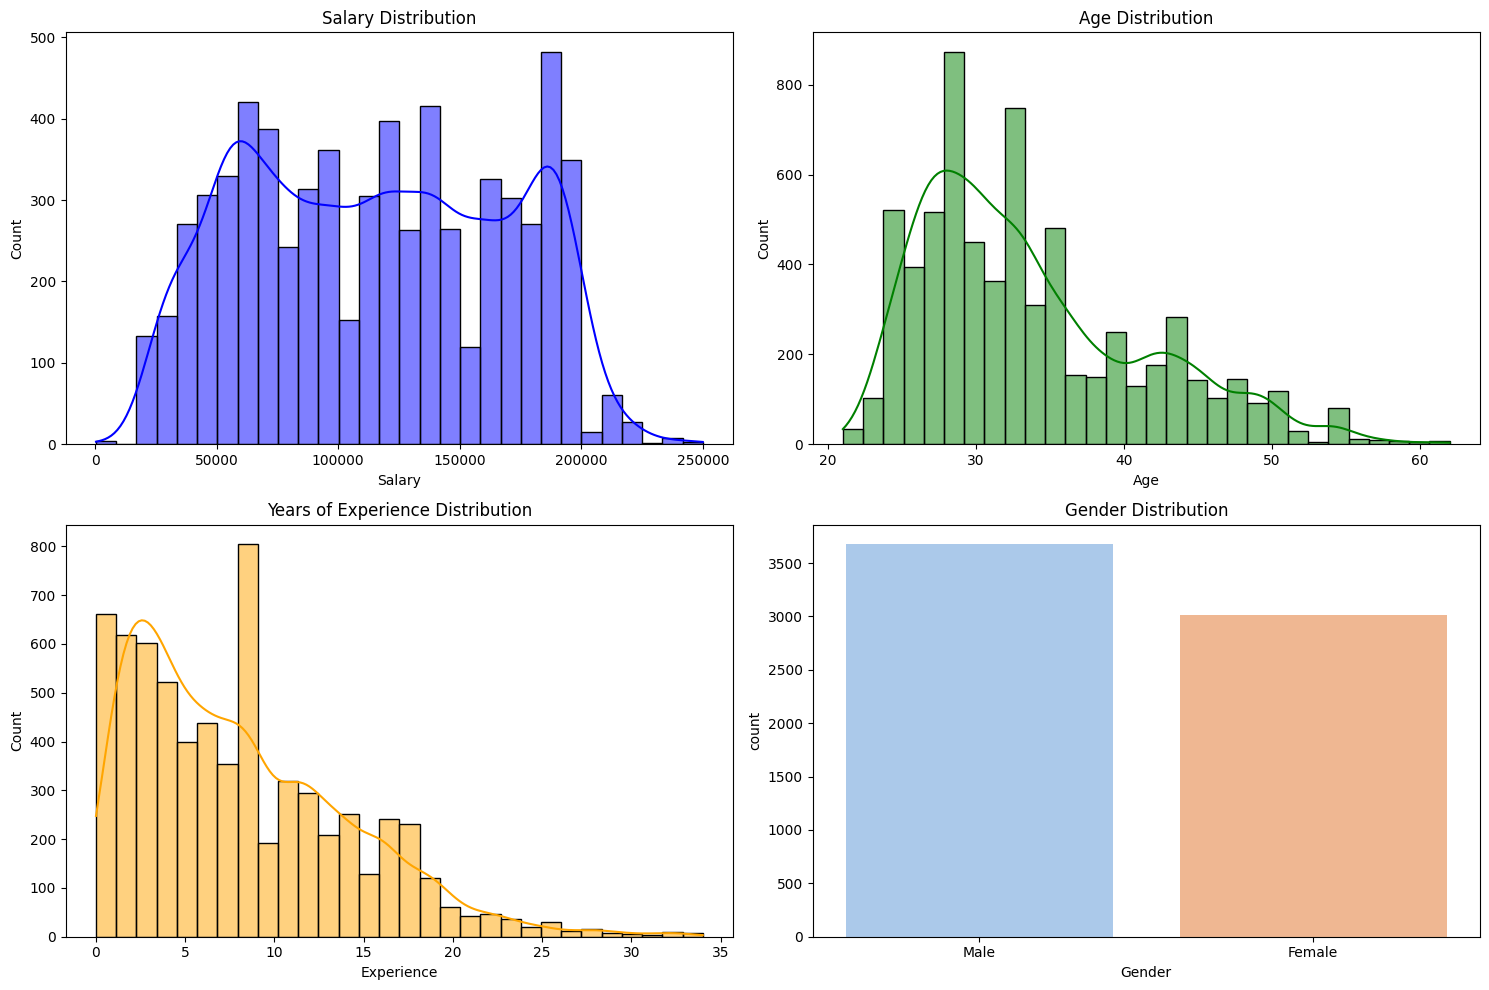

In [56]:
plt.figure(figsize=(15, 10))

# Salary distribution
plt.subplot(2, 2, 1)
sns.histplot(df['Salary'], kde=True, bins=30, color='blue')
plt.title('Salary Distribution')

# Age distribution 
plt.subplot(2, 2, 2)
sns.histplot(df['Age'], kde=True, bins=30, color='green')
plt.title('Age Distribution')

# Years of Experience distribution
plt.subplot(2, 2, 3)
sns.histplot(df['Experience'], kde=True, bins=30, color='orange')
plt.title('Years of Experience Distribution')

# Gender distribution
plt.subplot(2, 2, 4)
sns.countplot(x='Gender', data=df, palette='pastel')
plt.title('Gender Distribution')

plt.tight_layout()
plt.show()

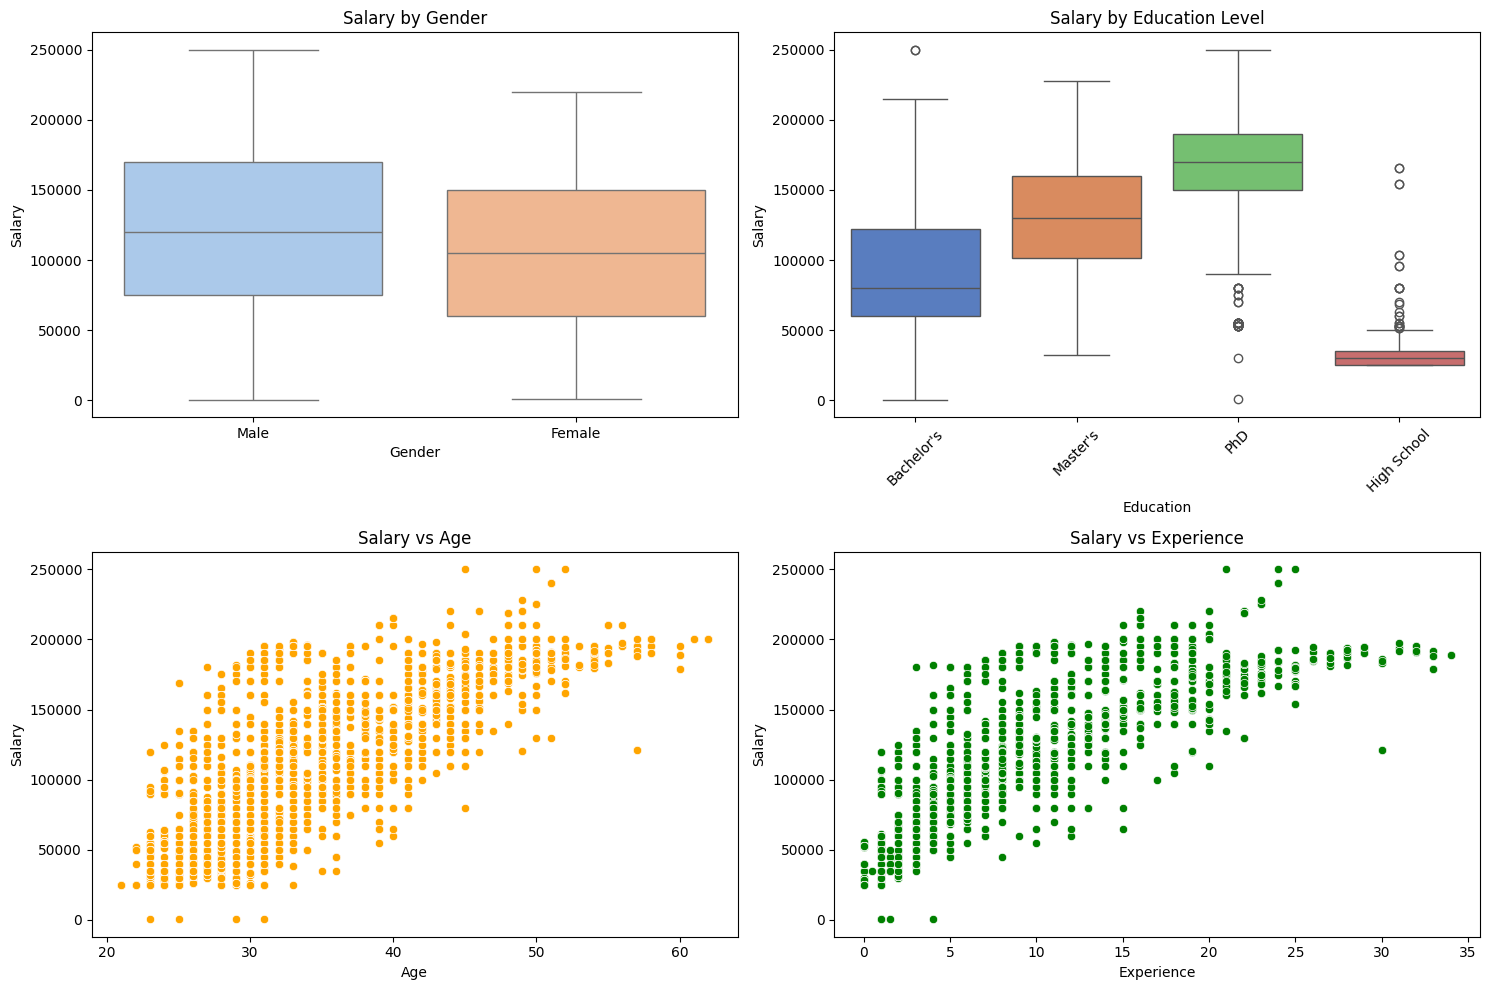

In [57]:
plt.figure(figsize=(15, 10))

# Salary by Gender
plt.subplot(2, 2, 1)
sns.boxplot(x='Gender', y='Salary', data=df, palette='pastel')
plt.title('Salary by Gender')

# Salary by Education Level
plt.subplot(2, 2, 2)
sns.boxplot(x='Education', y='Salary', data=df, palette='muted')
plt.title('Salary by Education Level')
plt.xticks(rotation=45)

# Salary vs Age
plt.subplot(2, 2, 3)
sns.scatterplot(x='Age', y='Salary', data=df, color='orange')
plt.title('Salary vs Age')

# Salary vs Experience
plt.subplot(2, 2, 4)
sns.scatterplot(x='Experience', y='Salary', data=df, color='green')
plt.title('Salary vs Experience')

plt.tight_layout()
plt.show()

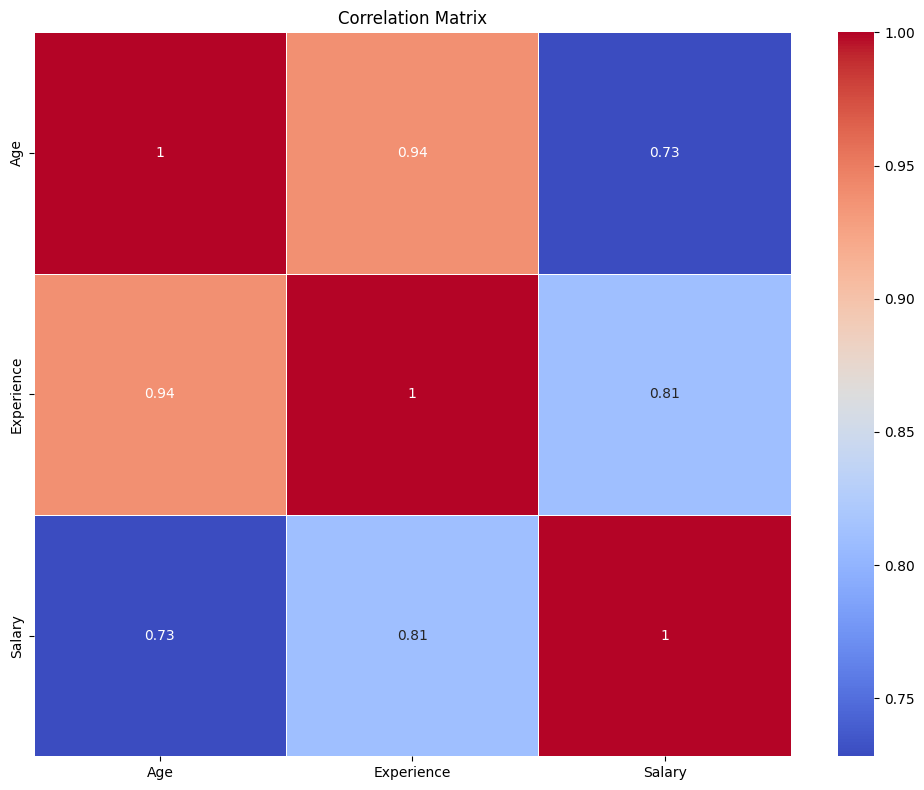

In [61]:
# Visualize the correlation matrix
numerical_df = df.select_dtypes(include=['float64', 'int64'])  # Select only numerical columns
corrolation_matrix = numerical_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corrolation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


## Data Preprocessing

In [105]:
# Split features and target
X = df.drop('Salary', axis=1)
y = df['Salary']

In [64]:
df

,Age,Gender,Education,Job,Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6683,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6684,32.0,Male,High School,Sales Associate,3.0,50000.0
6685,30.0,Female,Bachelor's,Financial Manager,4.0,55000.0
6686,46.0,Male,Master's,Marketing Manager,14.0,140000.0


In [93]:
categorical_features = ["Gender", "Education", "Job"]
numerical_features = ["Age", "Experience"]

`ColumnTransformer` allows different preprocessing steps for different columns of a dataset.


```python
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define categorical and numerical columns
categorical_features = ['gender', 'city']
numerical_features = ['age', 'salary']

# Create ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(), categorical_features)])

In [127]:
# Create ColumnTransformer
from sklearn.discriminant_analysis import StandardScaler


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler() , numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])


For Classification

Create a binary target `y_binary` to classify salary levels:

- **High**: if salary is **above** the median  
- **Low**: if salary is **below** the median


In [114]:
# Calculate the median salary
median_salary = df['Salary'].median()

# Create the binary target
y_binary = (df['Salary'] > median_salary).astype(int)  # 1 for High, 0 for Low

In [115]:
df['Salary']

0        90000.0
1        65000.0
2       150000.0
3        60000.0
4       200000.0
          ...   
6683    200000.0
6684     50000.0
6685     55000.0
6686    140000.0
6687     35000.0
Name: Salary, Length: 6688, dtype: float64

In [96]:
median_salary = df['Salary'].median()
# Create the binary target
print("Median Salary:", median_salary)

Median Salary: 115000.0


In [106]:
y_binary.value_counts()  # Check the distribution of the binary target

Salary
0    3378
1    3310
Name: count, dtype: int64

In [139]:
X = X[["Age", "Experience"]]
X

,Age,Experience
0,32.0,5.0
1,28.0,3.0
2,45.0,15.0
3,36.0,7.0
4,52.0,20.0
...,...,...
6683,49.0,20.0
6684,32.0,3.0
6685,30.0,4.0
6686,46.0,14.0


In [ ]:
# For regression task split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

numerical_preprocessor = ColumnTransformer(
	transformers=[
		('num', StandardScaler(), numerical_features)
	])

# Preprocess the training and testing data
X_train_processed = numerical_preprocessor.fit_transform(X_train)
X_test_processed = numerical_preprocessor.transform(X_test)#!ignore

In [136]:
X_train_processed.shape, X_test_processed.shape, y_train.shape, y_test.shape

((5350, 188), (1338, 188), (5350,), (1338,))

## 1. Regression: Predicting Salary

In [142]:
# Fit a linear regression model
linear_reg = LinearRegression()
linear_reg.fit(X_train_processed, y_train)

# Predict on the test set
y_pred = linear_reg.predict(X_test_processed)

# Evaluate the model with MSE and R^2 score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Linear Regression MSE: {mse}")
print(f"Linear Regression R^2: {r2}")

# Get the coefficients and intercept
coefficients = linear_reg.coef_
intercept = linear_reg.intercept_
print(f"Coefficients: {coefficients}")
print(f"Intercept: {intercept}")

Linear Regression MSE: 951558710.6640507
Linear Regression R^2: 0.6602179279984004
Coefficients: [-13295.48166416  55319.12655313]
Intercept: 115535.13341510844


In [148]:
# For classification task split data into training and testing sets
X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(df[categorical_features], y_binary, test_size=0.2, random_state=3)

# Create a new preprocessor for only categorical features
categorical_preprocessor = ColumnTransformer(
	transformers=[
		('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
	]
)

# Preprocess the training and testing data
X_train_binary_processed = categorical_preprocessor.fit_transform(X_train_binary)
X_test_binary_processed = categorical_preprocessor.transform(X_test_binary)

### 1.1 Filter-based Feature Selection

In [149]:
# Find the feature with the highest absolute correlation with Salary
most_correlated_feature = corrolation_matrix['Salary'].drop('Salary').abs().idxmax()

print("Feature selected based on Pearson correlation:", most_correlated_feature)

Feature selected based on Pearson correlation: Experience


### 1.2 Wrapper-based Feature Selection

In [156]:
# Perform Recursive Feature Elimination (RFE)
rfe_selector = RFE(estimator=LinearRegression(), n_features_to_select=1)
rfe_selector.fit(X_train, y_train)

# Get the selected features
selected_features_rfe = X_train.columns[rfe_selector.support_].tolist()

print("Features selected by RFE:", selected_features_rfe)

Features selected by RFE: ['Experience']


### 1.3 Embedded-based Feature Selection

In [154]:
# Grid Search to choose alpha (lambda) for Lasso and Ridge
param_grid = {'alpha': np.logspace(-3, 0, 30)}

In [157]:
# Perform Grid Search to find the best alpha for Lasso Regression
lasso = Lasso()
grid_search_lasso = GridSearchCV(estimator=lasso, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5)
grid_search_lasso.fit(X_train_processed, y_train)

# Get the best alpha value
best_alpha_lasso = grid_search_lasso.best_params_['alpha']
print("Best alpha for Lasso:", best_alpha_lasso)

# Fit Lasso Regression with the best alpha
lasso_best = Lasso(alpha=best_alpha_lasso)
lasso_best.fit(X_train_processed, y_train)

# Get the coefficients
lasso_coefs = lasso_best.coef_

# Features selected by Lasso (non-zero coefficients)
selected_features_lasso = [numerical_features[i] for i in range(len(lasso_coefs)) if lasso_coefs[i] != 0]
print("Features selected by Lasso:", selected_features_lasso)

Best alpha for Lasso: 1.0
Features selected by Lasso: ['Age', 'Experience']


What if we want to keep both experience and age and mitigate the high colinearity?

In [158]:
# Perform Grid Search to find the best alpha for Ridge Regression
ridge = Ridge()
grid_search_ridge = GridSearchCV(estimator=ridge, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5)
grid_search_ridge.fit(X_train_processed, y_train)

# Get the best alpha value
best_alpha_ridge = grid_search_ridge.best_params_['alpha']
print("Best alpha for Ridge:", best_alpha_ridge)

# Fit Ridge Regression with the best alpha
ridge_best = Ridge(alpha=best_alpha_ridge)
ridge_best.fit(X_train_processed, y_train)

# Get the coefficients
ridge_coefs = ridge_best.coef_
print("Ridge coefficients:", ridge_coefs)

Best alpha for Ridge: 1.0
Ridge coefficients: [-13194.60256434  55214.19448676]


## 2. Classification: Predicting High/Low Salary

In [159]:
# Fit a logistic regression model
logistic_reg = LogisticRegression(random_state=3, max_iter=1000)
logistic_reg.fit(X_train_binary_processed, y_train_binary)

# Predict on the test set
y_pred_log = logistic_reg.predict(X_test_binary_processed)

# Print the classification report
print("\nClassification Report (Logistic):\n", classification_report(y_test_binary, y_pred_log))


Classification Report (Logistic):
               precision    recall  f1-score   support

           0       0.79      0.83      0.81       679
           1       0.81      0.77      0.79       659

    accuracy                           0.80      1338
   macro avg       0.80      0.80      0.80      1338
weighted avg       0.80      0.80      0.80      1338



### 2.1 Filter-based Feature Selection for Classification with ANOVA F-test




In [160]:
# Apply ANOVA F-test
selector_anova = SelectKBest(score_func=f_classif, k='all')
X_train_binary_processed_dense = X_train_binary_processed.toarray()  # Convert sparse matrix to dense for compatibility
X_test_binary_processed_dense = X_test_binary_processed.toarray()

selector_anova.fit(X_train_binary_processed_dense, y_train_binary)

# Get the scores for each feature
scores_anova = selector_anova.scores_

print("ANOVA F-test scores for each feature:\n", scores_anova)

ANOVA F-test scores for each feature:
 [4.62864944e+01 4.62864944e+01 8.72715020e+02 3.71022515e+02
 1.78964378e+02 1.11486177e+03 9.82212369e-01 9.82212369e-01
 9.82212369e-01 1.96515311e+00 1.61227169e+01 9.82212369e-01
 9.82212369e-01 1.01810982e+00 1.01810982e+00 2.13423550e-01
 9.82212369e-01 1.01810982e+00 1.61005192e-04 9.82212369e-01
 5.90421605e+00 9.82212369e-01 9.82212369e-01 2.12002635e-01
 9.82212369e-01 3.27703019e+02 4.91835370e+00 9.82212369e-01
 9.82212369e-01 1.12407957e+01 1.38175514e+01 1.01810982e+00
 1.01810982e+00 4.76420681e+01 2.03698832e+00 2.03698832e+00
 6.18320662e+00 1.01810982e+00 3.09826133e+00 1.02157934e+01
 1.01810982e+00 1.01810982e+00 1.01810982e+00 1.96515311e+00
 9.82212369e-01 1.89389104e+01 4.14369175e+01 2.37757814e+01
 9.82571277e+01 7.52652205e-01 1.77919289e+01 1.01810982e+00
 9.82212369e-01 3.98647457e+01 1.01810982e+00 2.07969718e-01
 1.01810982e+00 9.82212369e-01 9.82212369e-01 1.96515311e+00
 1.96515311e+00 9.82212369e-01 6.89081085e+00 

In [161]:
# Select top 5 features using ANOVA
selector_anova_k = SelectKBest(score_func=f_classif, k=5)
X_train_binary_top_k = selector_anova_k.fit_transform(X_train_binary_processed_dense, y_train_binary)
X_test_binary_top_k = selector_anova_k.transform(X_test_binary_processed_dense)

# Train logistic regression on the selected features
log_clf = LogisticRegression(random_state=3, max_iter=1000)
log_clf.fit(X_train_binary_top_k, y_train_binary)

# Predict on the test set
y_pred_log = log_clf.predict(X_test_binary_top_k)

# Print the classification report
print("\nClassification Report (Logistic + ANOVA 5 features):\n", classification_report(y_test_binary, y_pred_log))


Classification Report (Logistic + ANOVA 5 features):
               precision    recall  f1-score   support

           0       0.73      0.75      0.74       679
           1       0.74      0.72      0.73       659

    accuracy                           0.74      1338
   macro avg       0.74      0.74      0.74      1338
weighted avg       0.74      0.74      0.74      1338



### 2.2 Wrapper-based Feature Selection for Classification

In [164]:
# Perform RFE with n_features_to_select=5
from sklearn.feature_selection import RFE

# Create logistic regression for the wrapper
log_model = LogisticRegression(random_state=3, max_iter=1000)

rfe_selector = RFE(estimator=log_model, n_features_to_select=5)
rfe_selector.fit(X_train_binary_processed_dense, y_train_binary)

# Get the selected features
selected_features_rfe = rfe_selector.support_

# Check which features were selected
print("Feature Ranking (RFE):", rfe_selector.ranking_)
# print("Selected Features (RFE):", selected_features_rfe)

Feature Ranking (RFE): [ 78 178 176   1  30  28 154 152 175 125  52 102 103  63 129  49 174  83
  84 151 153 150 171  34 173   8 177 149 172 130  35  97  96   7  57  46
  55  82  53  22  93  94 106 124 115  25  24  19  67  47  20  61 141  13
  79  50  62 148 143 117 107 142  64  65 108 169 147  21 114 170 145 146
  72  37  16 123  86  11  88  71 157 144  77  70 164 116  41  36 158 159
  12  10 134  17 180 179   1  87   4  51 135 163 136 119 128 126   1  27
 100 101  29 109  98 168   3   6  42  31  95  32 140  15 165 162 166 167
 182 104  54  43   5  69  48 181 110  14  56  80 160 118  81  68  59 139
  85  40 161 105  73  89 138 121  66  44 137  45 120  76  18  26   9 127
  39 122  75  91  99  23 113  74  58 156  38   1  33   2  92  60 133 132
 131 155 111 112  90   1]


In [165]:
# Perform prediction using the RFE-selected features
y_pred_rfe = rfe_selector.estimator_.predict(X_test_binary_processed_dense[:, rfe_selector.support_])

# Print the classification report
print("\nClassification Report (Logistic + RFE):\n", classification_report(y_test_binary, y_pred_rfe))


Classification Report (Logistic + RFE):
               precision    recall  f1-score   support

           0       0.99      0.27      0.43       679
           1       0.57      1.00      0.73       659

    accuracy                           0.63      1338
   macro avg       0.78      0.63      0.58      1338
weighted avg       0.78      0.63      0.57      1338



### 2.3 Embedded-based Feature Selection for Classification

In [166]:
# Use L1 regularization to select features
log_model_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=3, max_iter=1000)
log_model_l1.fit(X_train_binary_processed_dense, y_train_binary)

# Check which coefficients are zero and which are non-zero
# Non-zero coefficients indicate selected features
coef_l1 = log_model_l1.coef_[0]
selected_features = np.flatnonzero(coef_l1)  # indices of non-zero coefficients
print("Selected feature indices (non-zero in L1):", selected_features)

Selected feature indices (non-zero in L1): [  0   2   3   5  10  15  23  25  30  33  35  36  38  39  45  46  47  48
  49  50  53  55  62  63  67  73  74  77  87  90  91  93  96  97  98  99
 103 106 107 110 114 115 117 119 121 128 129 130 132 135 136 139 145 148
 152 153 155 158 159 160 162 167 172 173 174 175 185]


In [167]:
# Predict on the test set using the L1-regularized logistic regression model
y_pred_l1 = log_model_l1.predict(X_test_binary_processed_dense)

# Evaluate classification performance
print("\nClassification Report (Logistic + L1 Embedded):\n", classification_report(y_test_binary, y_pred_l1))


Classification Report (Logistic + L1 Embedded):
               precision    recall  f1-score   support

           0       0.79      0.83      0.81       679
           1       0.81      0.77      0.79       659

    accuracy                           0.80      1338
   macro avg       0.80      0.80      0.80      1338
weighted avg       0.80      0.80      0.80      1338

